In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#upload
try:
    from google.colab import files
    print("Please upload knndataset.txt")
    uploaded = files.upload()
    DATA_FILE = 'knndataset.txt'
except ImportError:
    DATA_FILE = 'knndataset.txt'

train_points = []
train_labels = []

with open(DATA_FILE, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 3:
            train_points.append([float(parts[0]), float(parts[1])])
            train_labels.append(int(float(parts[2])))

print(f"Loaded {len(train_points)} training points")


Please upload knndataset.txt


Saving knndataset.txt to knndataset.txt
Loaded 100 training points


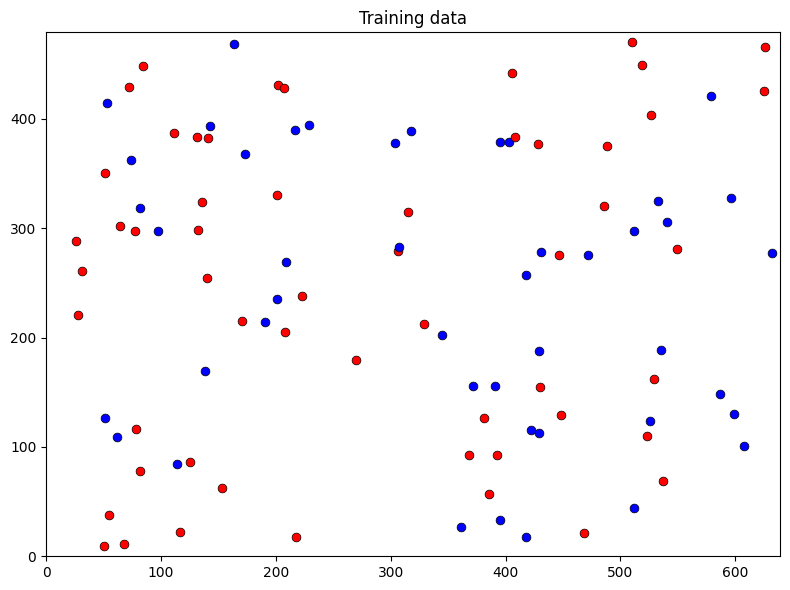

In [3]:
colors = ["red" if label == 0 else "blue" for label in train_labels]

plt.figure(figsize=(8, 6))
for i in range(len(train_points)):
    plt.scatter(train_points[i][0], train_points[i][1],
                color=colors[i], s=40, edgecolors='black', linewidths=0.5)

plt.title("Training data")
plt.xlim([0, 639])
plt.ylim([0, 479])
plt.tight_layout()
plt.show()

In [4]:
# k-nn
def dist_squared(p1, p2):
    dx = p1[0] - p2[0]
    dy = p1[1] - p2[1]
    return dx*dx + dy*dy

def knn_classify(test_point, train_points, train_labels, K, use_weights=False):


    distances = []
    for i in range(len(train_points)):
        d2 = dist_squared(test_point, train_points[i])
        distances.append((d2, i))

    distances.sort(key=lambda x: x[0])
    k_nearest = distances[:K]


    if not use_weights:

        count_0 = 0
        count_1 = 0
        for d2, idx in k_nearest:
            if train_labels[idx] == 0:
                count_0 += 1
            else:
                count_1 += 1

        return 0 if count_0 >= count_1 else 1

    else:

        weight_0 = 0.0
        weight_1 = 0.0
        for d2, idx in k_nearest:
            if d2 == 0:
                return train_labels[idx]
            w = 1.0 / d2
            if train_labels[idx] == 0:
                weight_0 += w
            else:
                weight_1 += w

        return 0 if weight_0 >= weight_1 else 1

In [9]:

def build_decision_region(train_points, train_labels, K, use_weights):

    grid_width  = 320
    grid_height = 240
    step_x = 639 / (grid_width  - 1)
    step_y = 479 / (grid_height - 1)

    grid_points = []
    for col in range(grid_width):
        for row in range(grid_height):
            grid_points.append([col * step_x, row * step_y])

    total = len(grid_points)
    print(f"Classifying {total} grid points  (K={K}, weighted={use_weights})")

    grid_labels = []
    for i, point in enumerate(grid_points):
        label = knn_classify(point, train_points, train_labels, K, use_weights)
        grid_labels.append(label)

    color_map = plt.get_cmap('Set1')
    image = color_map(grid_labels)
    image = image.reshape([grid_width, grid_height, 4])
    image = np.transpose(image, [1, 0, 2])

    return image, [0, 639, 0, 479]


Classifying 76800 grid points  (K=3, weighted=False)


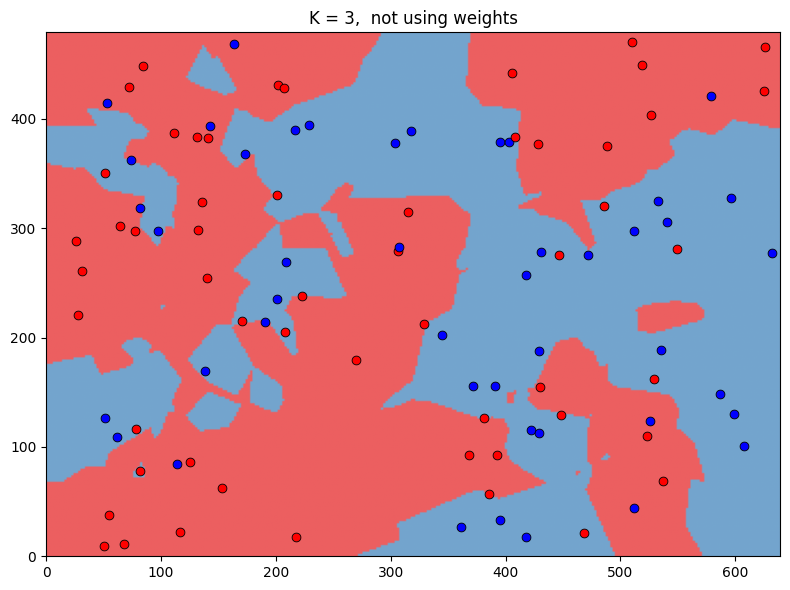

In [10]:
K = 3
use_weights = False

image, extent = build_decision_region(train_points, train_labels, K, use_weights)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(image, extent=extent, origin='lower', aspect='auto', alpha=0.7)

point_colors = ["red" if l == 0 else "blue" for l in train_labels]
for i in range(len(train_points)):
    ax.scatter(train_points[i][0], train_points[i][1],
               color=point_colors[i], s=40,
               edgecolors='black', linewidths=0.6, zorder=5)

ax.set_title(f"K = {K},  {'using weights' if use_weights else 'not using weights'}")
plt.tight_layout()
plt.show()